Successfully imported necessary libraries for exploritory analysis

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
from scipy.stats import pearsonr
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Import dataframes for Exploratory Data Analysis

In [48]:
life_expectancy = pd.read_csv('../Datasets/Cleaned_datasets/Life_expectancy_cleaned_1.csv').drop(columns=['Unnamed: 0'])

highest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Top_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])
lowest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Lowest_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])


In [49]:
descriptive_stats_life_exp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats_All_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

descriptive_stats_life_exp_top_gdp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats-Top_GDP_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

descriptive_stats_life_exp_bottom_gdp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats-Bottom_GDP_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

In [50]:
descriptive_stats_adult_mortality = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats_All_Adult_Mortality.csv')

# Explore relationship between life expectancy and GDP per capita

Display life expectancy descriptive analysis stats for lowest gdp per capita countries for the countries falling into those categories in 2015.

## Summary Statistics

In [51]:
#region life expectancy 
# print(life_expectancy.describe(include='all'))
print(descriptive_stats_life_exp_bottom_gdp)


    year   mean    max  minimum               min_country  median
0   2000  52.21  63.26    44.52                    Malawi   50.54
1   2001  52.90  64.06    45.39  Central African Republic   51.06
2   2002  53.59  64.85    45.41  Central African Republic   51.40
3   2003  54.33  65.55    45.76  Central African Republic   52.71
4   2004  55.21  66.03    46.04  Central African Republic   53.39
5   2005  55.94  66.51    46.43  Central African Republic   54.00
6   2006  56.68  67.01    46.85  Central African Republic   54.88
7   2007  57.35  67.22    47.43  Central African Republic   55.99
8   2008  57.68  67.69    48.02  Central African Republic   56.51
9   2009  58.65  68.04    48.65  Central African Republic   58.10
10  2010  59.13  67.74    49.26  Central African Republic   58.90
11  2011  59.78  68.42    49.95  Central African Republic   59.30
12  2012  60.34  68.92    50.54                      Chad   59.78
13  2013  60.84  69.30    50.78                      Chad   60.09
14  2014  

Also display life expectancy descriptive analysis stats for highest gdp per capita countries for the countries falling into those categories in 2015.

In [52]:
print(descriptive_stats_life_exp_top_gdp)

    year   mean    max  max_country  minimum  median
0   2000  77.58  81.08        Japan    72.04   77.90
1   2001  77.91  81.42        Japan    72.11   78.09
2   2002  78.05  81.69        Japan    72.23   78.18
3   2003  78.31  81.76        Japan    72.40   78.41
4   2004  78.74  82.03        Japan    72.48   78.99
5   2005  78.95  81.96        Japan    72.76   79.19
6   2006  79.20  82.32        Japan    72.86   79.34
7   2007  79.42  82.51        Japan    72.68   79.71
8   2008  79.67  82.59        Japan    72.67   80.18
9   2009  79.90  82.93        Japan    72.58   80.26
10  2010  80.13  82.84        Japan    72.73   80.60
11  2011  80.44  82.70  Switzerland    72.56   80.96
12  2012  80.59  83.10        Japan    72.75   80.92
13  2013  80.73  83.33        Japan    73.02   81.07
14  2014  81.08  83.59        Japan    73.37   81.42
15  2015  81.03  83.79        Japan    73.10   81.46


Calculate number of unique countries for both lowest and highest grossing countries from 2000 to 2015, to observe how many countries circulated in the highest and lowest gdp per capita area during the 16 years.

In [53]:
unique_highest_gdp_counries = []

for year in range(2000, 2016):
    le_highest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=False).reset_index(drop=True)
    le_highest_20_gdp = le_highest_20_gdp.iloc[:20]
    for country in list(le_highest_20_gdp['country']):
        if country not in unique_highest_gdp_counries:
            unique_highest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_highest_gdp_counries))} unique countries in the 20 highest grossing counries per capita range from 2000 to 2015')

unique_lowest_gdp_counries = []

for year in range(2000, 2016):
    le_lowest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=True).reset_index(drop=True)
    le_lowest_20_gdp = le_lowest_20_gdp.iloc[:20]
    for country in list(le_lowest_20_gdp['country']):
        if country not in unique_lowest_gdp_counries:
            unique_lowest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_lowest_gdp_counries))} unique countries in the 20 lowest grossing counries per capita range from 2000 to 2015')

There are 26 unique countries in the 20 highest grossing counries per capita range from 2000 to 2015
There are 30 unique countries in the 20 lowest grossing counries per capita range from 2000 to 2015


## Correlation Matrices and Heatmaps

### Complete dataset

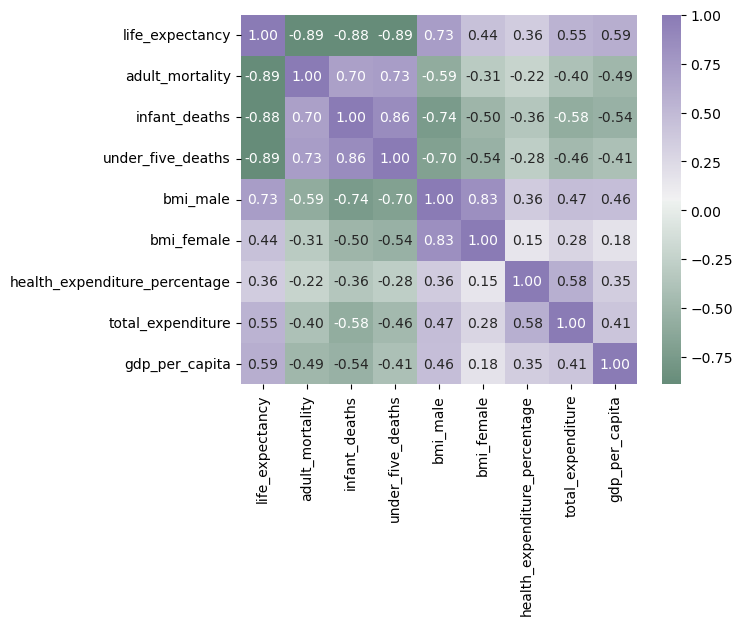

<Figure size 640x480 with 0 Axes>

In [54]:
# Dropping countries with missing values for columns adult_mortality, infant_deaths, under_five_deaths, health_expenditure_percentage, total_expenditure or unemployment_total does not affect correlation
#na_countries = ['Côte d\'Ivoire', 'Netherlands', 'The former Yugoslav republic of Macedonia', 'Turkey']
#life_expectancy_heatmap = life_expectancy[~(life_expectancy['country'].isin(na_countries))]


life_expectancy_temp = life_expectancy.copy()

# region and sub-region categories don't show significant correlation
# life_expectancy_temp['sub_region'] = LabelEncoder().fit_transform(life_expectancy_temp['sub_region'])
# life_expectancy_temp['region'] = LabelEncoder().fit_transform(life_expectancy_temp['region'])
# life_expectancy_temp['sub_region'] = life_expectancy_temp['sub_region'].astype('float64')
# life_expectancy_temp['region'] = life_expectancy_temp['region'].astype('float64')

life_expectancy_heatmap = life_expectancy_temp.select_dtypes('float64')

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(life_expectancy_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()


### Regions

#### African region

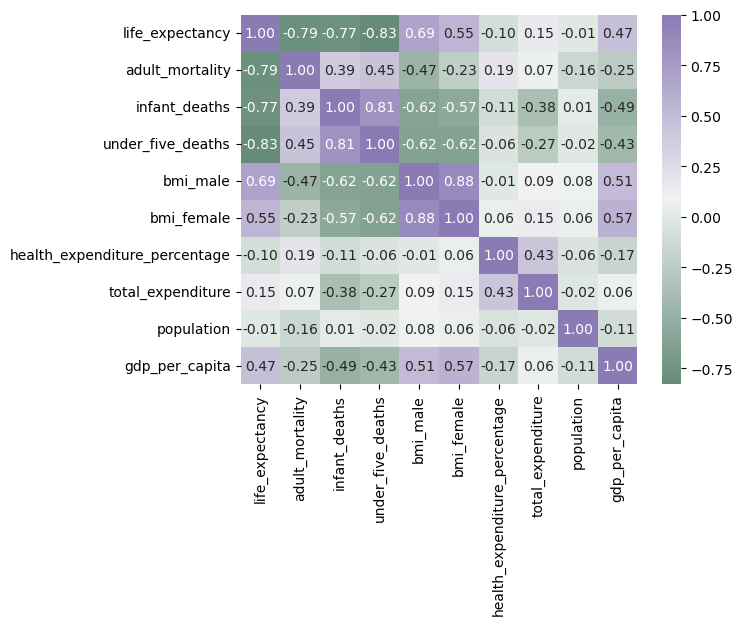

<Figure size 640x480 with 0 Axes>

In [55]:
african_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'African region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(african_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### Asian region

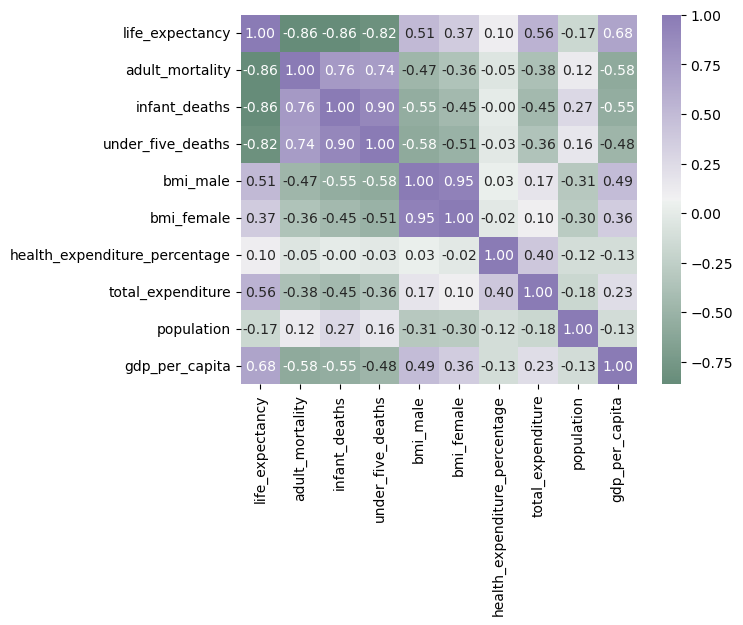

<Figure size 640x480 with 0 Axes>

In [56]:
asian_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'Asian region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(asian_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### European region

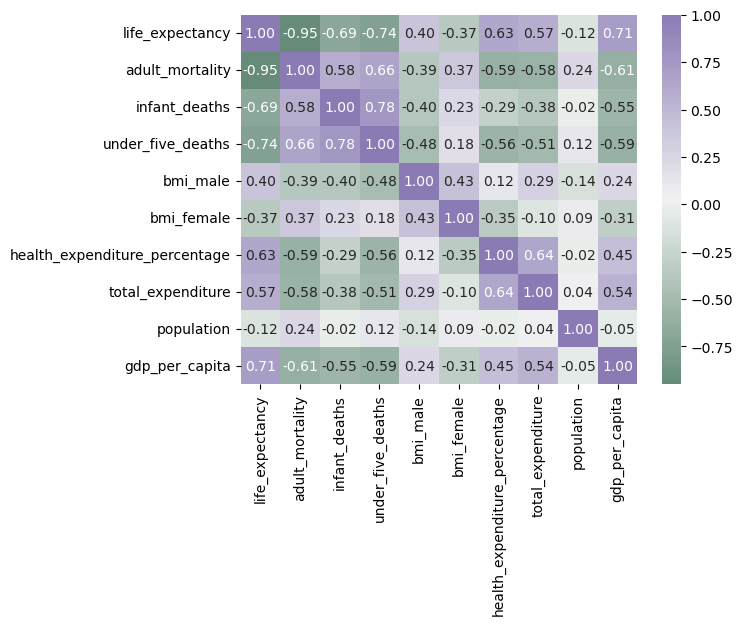

<Figure size 640x480 with 0 Axes>

In [57]:
european_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'European region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(european_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### American region

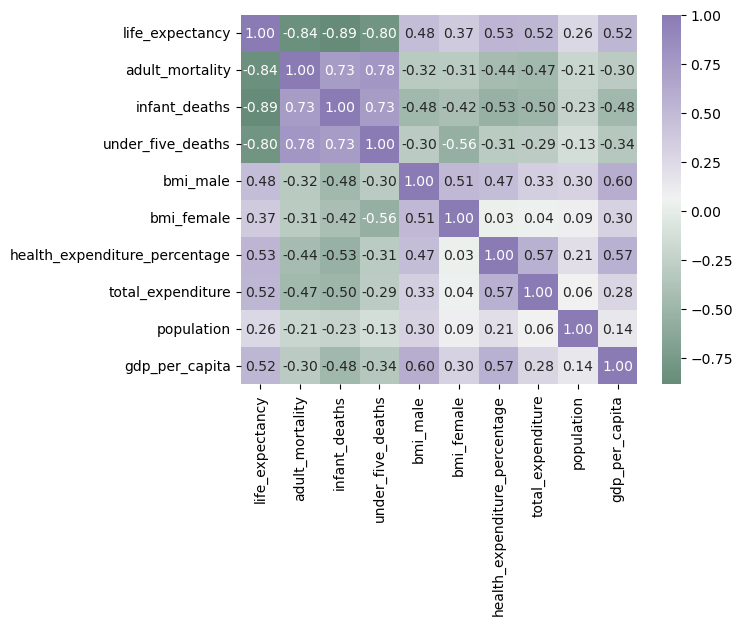

<Figure size 640x480 with 0 Axes>

In [58]:
american_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'American region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(american_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### Oceania region

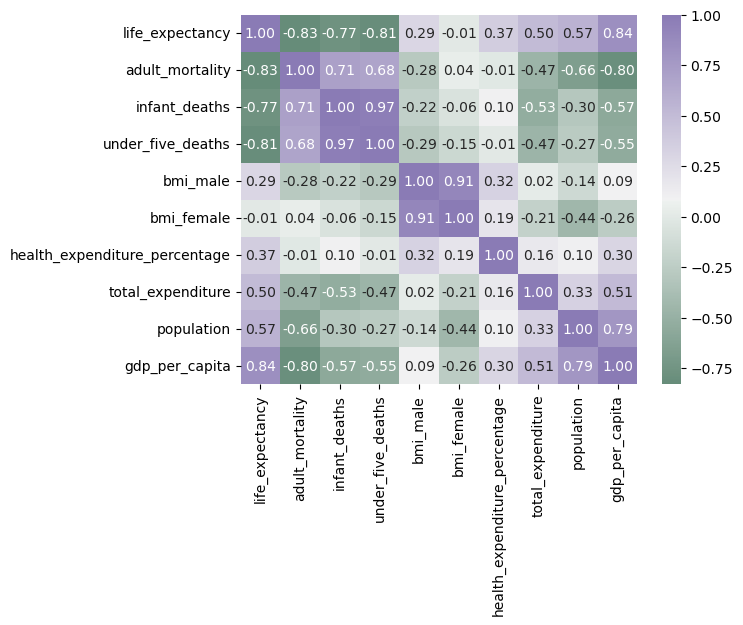

<Figure size 640x480 with 0 Axes>

In [59]:
oceania_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'Oceania region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(oceania_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

### Top GDP

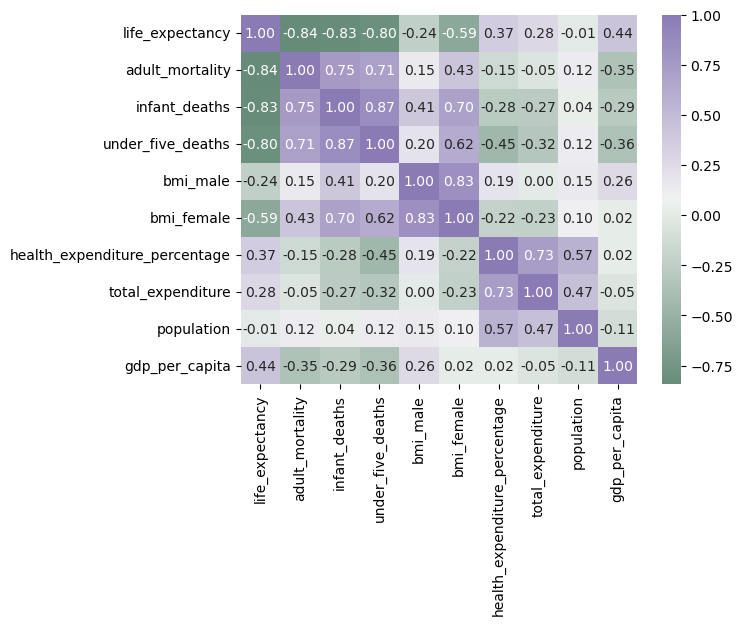

<Figure size 640x480 with 0 Axes>

In [60]:
highest_grossing_heatmap = highest_grossing[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(highest_grossing_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

### Lowest GDP

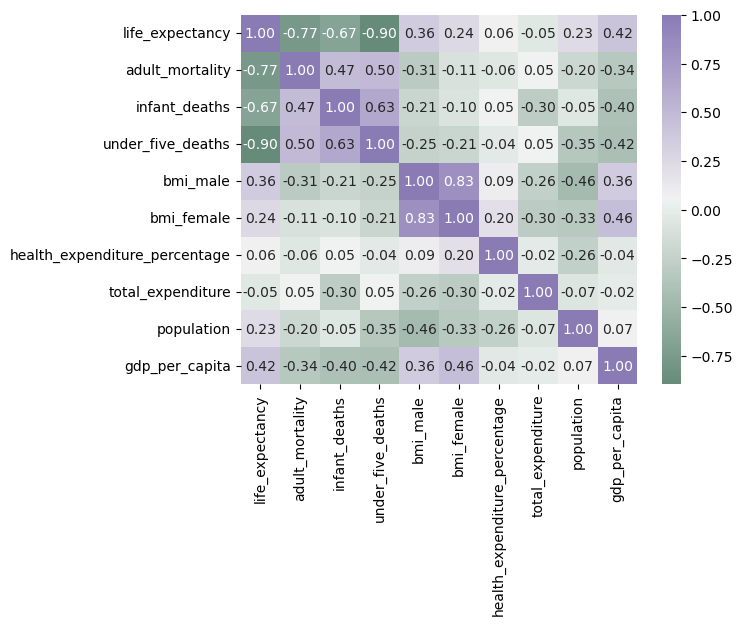

<Figure size 640x480 with 0 Axes>

In [61]:
lowest_grossing_heatmap = lowest_grossing[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(lowest_grossing_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

## Scatterplots

### Life Expectancy vs GDP

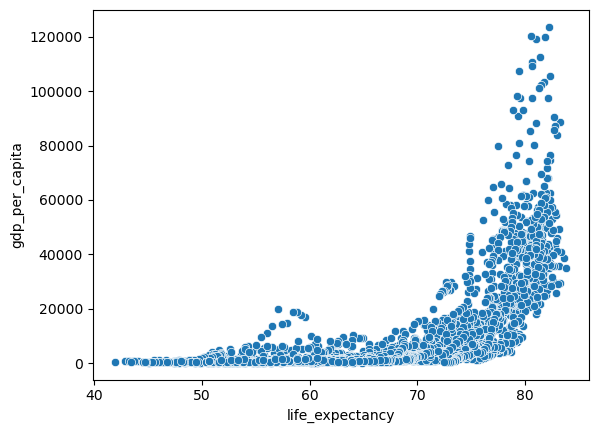

[[8.18964954e+01 9.15954776e+04]
 [9.15954776e+04 2.91856924e+08]]
0.5924563692949664


<Figure size 640x480 with 0 Axes>

In [62]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['gdp_per_capita'])
plt.show()
plt.clf()

print(np.cov(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita']))
cor_life_exp_gdp, p = pearsonr(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita'])
print(cor_life_exp_gdp)


### Life Expectancy vs Male BMI

In [63]:
gdp_class = []
for gdp in list(life_expectancy['gdp_per_capita']):
    if gdp >= 15000:
        gdp_class.append('more than 15,000')
    else:
        gdp_class.append('less than 15,000')

life_expectancy['gdp_class'] = gdp_class

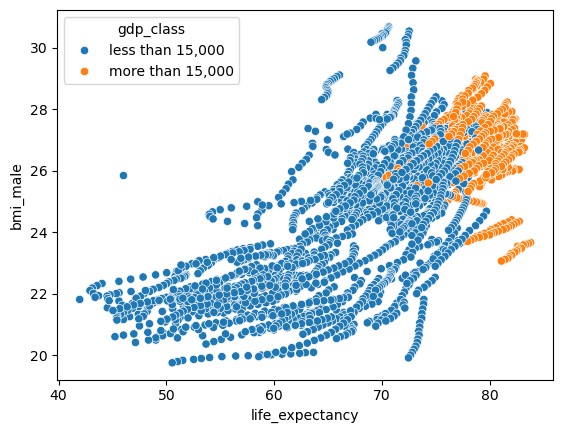

<Figure size 640x480 with 0 Axes>

In [64]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['bmi_male'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

### Life Expectancy vs Female BMI

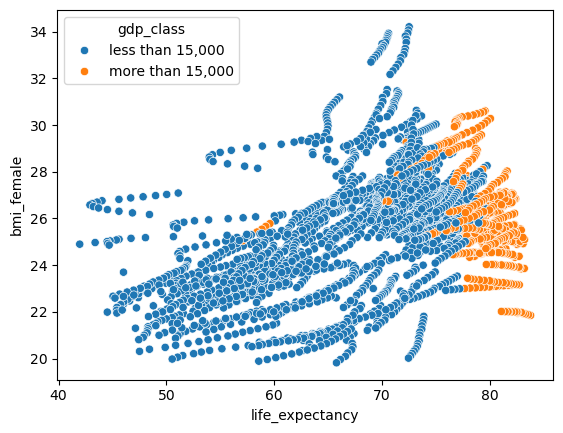

<Figure size 640x480 with 0 Axes>

In [65]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['bmi_female'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()


### Life Expectancy vs Adult Mortality

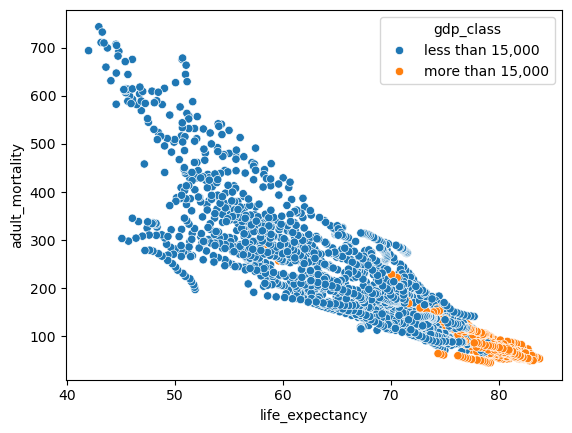

<Figure size 640x480 with 0 Axes>

In [66]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['adult_mortality'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

In [67]:
print(np.cov(life_expectancy['life_expectancy'], life_expectancy['adult_mortality']))
cor_life_exp_ad_mortality, p = pearsonr(life_expectancy['life_expectancy'], life_expectancy['adult_mortality'])
print(np.round(cor_life_exp_ad_mortality, 2))


[[   81.89649536  -935.17878942]
 [ -935.17878942 13477.95418657]]
-0.89


### Life Expectancy vs Infant Mortality

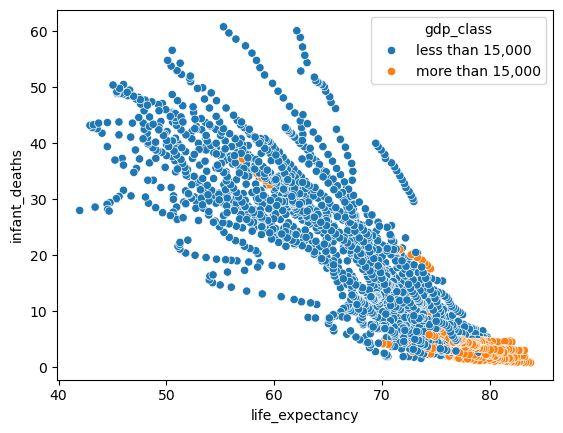

<Figure size 640x480 with 0 Axes>

In [68]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['infant_deaths'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

### Life Expectancy vs Under 5 Mortality

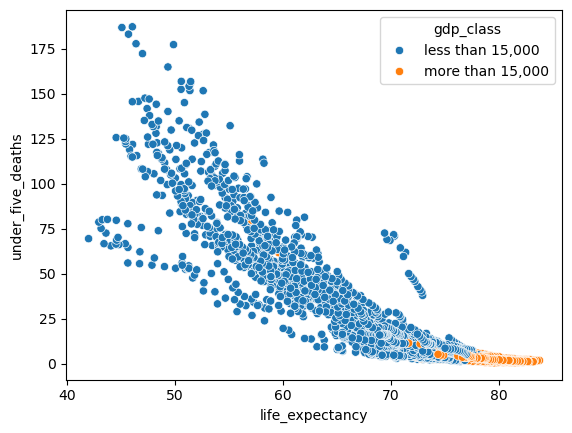

<Figure size 640x480 with 0 Axes>

In [69]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['under_five_deaths'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

In [70]:
high_gdp_outlier = life_expectancy[(life_expectancy['life_expectancy'] < 60) & (life_expectancy['gdp_class'] == 'more than 15,000')]
print(np.unique(high_gdp_outlier['country']))
print(descriptive_stats_life_exp)


['Equatorial Guinea']
    year   mean    max max_countries  minimum min_countries  median   std
0   2000  66.77  81.08         Japan    44.52        Malawi   69.75  9.76
1   2001  67.10  81.42         Japan    41.96      Zimbabwe   69.96  9.77
2   2002  67.38  81.69         Japan    44.56      Zimbabwe   70.44  9.64
3   2003  67.67  81.76         Japan    43.39      Zimbabwe   70.72  9.54
4   2004  68.03  82.03         Japan    43.71       Lesotho   70.86  9.45
5   2005  68.38  81.96         Japan    43.23       Lesotho   71.25  9.31
6   2006  68.76  82.32         Japan    42.91       Lesotho   71.20  9.15
7   2007  69.10  82.51         Japan    43.12       Lesotho   71.42  8.99
8   2008  69.43  82.59         Japan    43.57       Lesotho   71.66  8.87
9   2009  69.84  82.93         Japan    44.03       Lesotho   71.95  8.67
10  2010  70.14  82.84         Japan    45.60       Lesotho   72.37  8.67
11  2011  70.60  82.70   Switzerland    46.69       Lesotho   72.56  8.36
12  2012  70.88 

## Box Plots

### Life Expectancy vs GDP

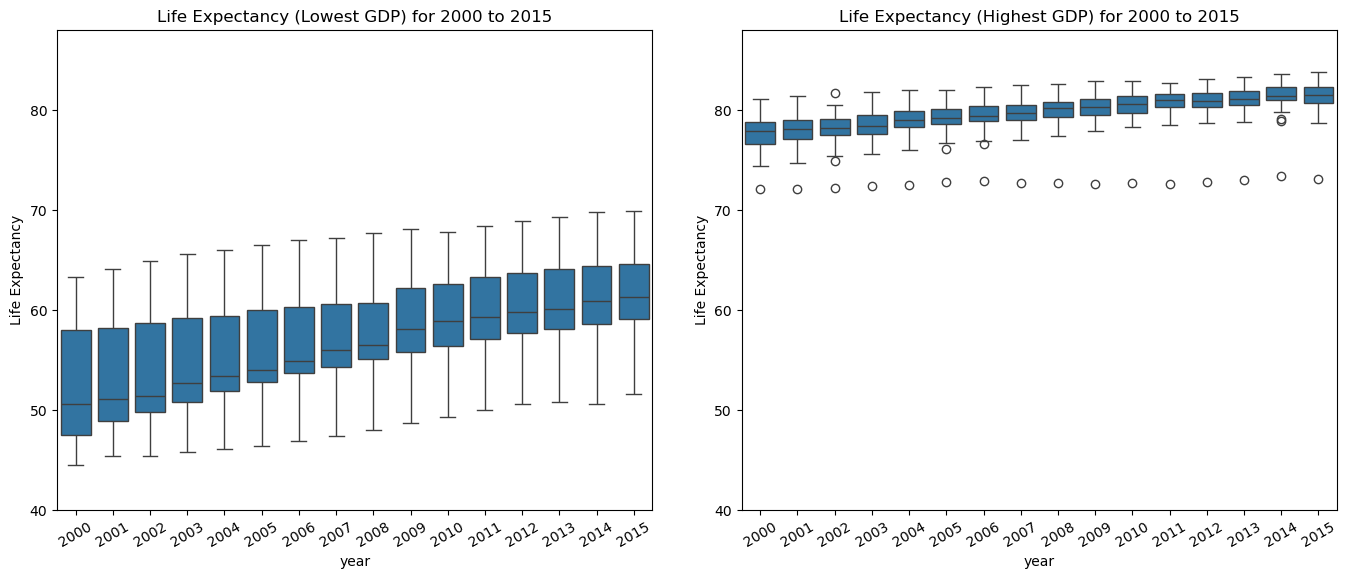

<Figure size 640x480 with 0 Axes>

In [71]:

ax2 = plt.subplot(1, 2, 1)
sns.boxplot(x = le_bottom_2000_to_2015['year'], y = le_bottom_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (Lowest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.subplots_adjust(0, 1, 2, 2, 0.15, 0)
ax4 = plt.subplot(1, 2, 2)
sns.boxplot(x = le_top_2000_to_2015['year'], y = le_top_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (Highest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.show()
plt.clf()